## Notebook Overview
## Classical Machine Learning Models and Gaussian Process Classifier

- This notebook evaluates the performance and predictive uncertainty of several classical machine‑learning classifiers applied to a radiomics‑based prostate cancer dataset. After loading and balancing the data (undersampling ISUP 0 and applying SMOTE), the notebook performs nested cross‑validation combined with hyperparameter tuning across five different model families:
    - Logistic Regression
    - K‑Nearest Neighbors (KNN)
    - Random Forest
    - XGBoost
    - Gaussian Process Classifier (GPC)

- For every model and feature set, the notebook reports:
    - Accuracy
    - ROC‑AUC
    - Confusion Matrix
    - Classification Report
    - Predictive Uncertainty
    - Uncertainty per predicted class
    - ROC curves for all models on the same plot


- The goal is to compare how these models behave under the same evaluation framework, identify the best‑performing configuration for each, and analyze their predictive uncertainty.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.gaussian_process import GaussianProcessClassifier

from scipy.stats import entropy

from deep_gp.preprocessing_data import load_data, undersample_class0, apply_smote

%matplotlib inline


In [ ]:
# Load original data
data = load_data()

# Step 1: undersample class 0
df_new = undersample_class0(data)

# Step 2: apply SMOTE on the undersampled dataset
df_resampled = apply_smote(df_new)

# Step 3: binary target on SMOTE-balanced dataset
# 0–2 → 0, 3–5 → 1
df_resampled["binary_target"] = (df_resampled["case_ISUP"] >= 3).astype(int)

X_resampled = df_resampled.drop(columns=["case_ISUP", "binary_target"])
y_resampled = df_resampled["binary_target"]


In [ ]:

def evaluate_models_cv_with_tuning(X, y, label):

    print(f"\n=== Feature set: {label} ===")

    # base models
    base_models = {
        "Logistic Regression": LogisticRegression(
            solver="saga",
            max_iter=30000,
            tol=1e-4
        ),
        "KNN": KNeighborsClassifier(),
        "Random Forest": RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ),
        "XGBoost": XGBClassifier(
            eval_metric="logloss",
            random_state=42
        ),
        "Gaussian Process": GaussianProcessClassifier(
            kernel=C(1.0, (1e-6, 1e6)) *
                   RBF(length_scale=1.0, length_scale_bounds=(1e-6, 1e6)) +
                   WhiteKernel(noise_level=1e-3),
            n_restarts_optimizer=2,
            random_state=42
        )
    }


    # hyperparameter grids

    # Logistic Regression
    param_grid_lr = {
        "C": [0.01, 0.1, 1.0]  # default C=1.0 included
    }

    # Knn
    param_grid_knn = {
        "n_neighbors": [3, 5, 7, 9],  
        "weights": ["uniform", "distance"]  
    }

    # Random Forest
    param_dist_rf = {
        "n_estimators": [100, 200, 300, 400, 500], 
        "max_depth": [None, 5, 10, 20],  
        "min_samples_split": [2, 5, 10],  
        "min_samples_leaf": [1, 2, 4],  
        "max_features": ["sqrt", "log2", None]  
    }

    # XGBoost
    param_dist_xgb = {
        "n_estimators": [100, 200, 300, 400],  
        "learning_rate": [0.01, 0.05, 0.1, 0.3],  
        "max_depth": [3, 4, 5, 6],  
        "subsample": [0.7, 0.8, 0.9, 1.0],  
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0]  
    }

    # Gaussian Process Classifier
    kernel_list = [
        C(c, (1e-6, 1e6)) *
        RBF(length_scale=l, length_scale_bounds=(1e-6, 1e6)) +
        WhiteKernel(noise_level=1e-3)
        for c in [0.5, 1.0, 2.0]  
        for l in [0.5, 1.0, 2.0]  
    ]

    # include default kernel: RBF(1.0)
    kernel_list.append(RBF(1.0))

    param_grid_gpc = {
        "kernel": kernel_list,
        "n_restarts_optimizer": [0, 2] 
    }

    
    # inner cv
    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    tuned_models = {
        "Logistic Regression": GridSearchCV(
            base_models["Logistic Regression"],
            param_grid_lr,
            cv=cv_inner,
            scoring="roc_auc",
            n_jobs=-1
        ),
        "KNN": GridSearchCV(
            base_models["KNN"],
            param_grid_knn,
            cv=cv_inner,
            scoring="roc_auc",
            n_jobs=-1
        ),
        "Random Forest": RandomizedSearchCV(
            base_models["Random Forest"],
            param_dist_rf,
            n_iter=20,
            cv=cv_inner,
            scoring="roc_auc",
            n_jobs=-1,
            random_state=42
        ),
        "XGBoost": RandomizedSearchCV(
            base_models["XGBoost"],
            param_dist_xgb,
            n_iter=20,
            cv=cv_inner,
            scoring="roc_auc",
            n_jobs=-1,
            random_state=42
        ),
        "Gaussian Process": GridSearchCV(
            base_models["Gaussian Process"],
            param_grid_gpc,
            cv=cv_inner,
            scoring="roc_auc",
            n_jobs=-1
        )
    }

    best_models = {}
    for name, tuner in tuned_models.items():
        print(f"\n>>> Tuning {name} ...")
        tuner.fit(X, y)
        print("Best params:", tuner.best_params_)
        best_models[name] = tuner.best_estimator_

    
    # outer cv evaluation
    skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    roc_curves = {}

    for name, model in best_models.items():
        print(f"\n=== Evaluation: {name} ===")

        y_pred_all = np.zeros(len(y))
        y_prob_all = np.zeros(len(y))
        uncertainty_all = np.zeros(len(y))

        for train_idx, test_idx in skf_outer.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled  = scaler.transform(X_test)

            model.fit(X_train_scaled, y_train)

            y_prob = model.predict_proba(X_test_scaled)[:, 1]
            y_pred = model.predict(X_test_scaled)

            if name == "Gaussian Process":
                uncertainty = y_prob * (1 - y_prob)
            else:
                uncertainty = entropy(
                    np.vstack([y_prob, 1 - y_prob]),
                    base=2
                )

            y_pred_all[test_idx] = y_pred
            y_prob_all[test_idx] = y_prob
            uncertainty_all[test_idx] = uncertainty

        print("Accuracy:", accuracy_score(y, y_pred_all))
        print("ROC-AUC:", roc_auc_score(y, y_prob_all))
        print("Mean uncertainty:", uncertainty_all.mean())
        print("Confusion matrix:\n", confusion_matrix(y, y_pred_all))
        print(classification_report(y, y_pred_all))

        print("Uncertainty for class 0:", uncertainty_all[y_pred_all == 0].mean())
        print("Uncertainty for class 1:", uncertainty_all[y_pred_all == 1].mean())

        fpr, tpr, _ = roc_curve(y, y_prob_all)
        roc_auc = auc(fpr, tpr)
        roc_curves[name] = (fpr, tpr, roc_auc)

    # Plot of curves
    plt.figure(figsize=(8, 6))
    for model_name, (fpr, tpr, roc_auc) in roc_curves.items():
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — {label}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()



=== Feature set: All features ===

>>> Tuning Logistic Regression ...
Best params: {'C': 0.1}

>>> Tuning KNN ...
Best params: {'n_neighbors': 9, 'weights': 'distance'}

>>> Tuning Random Forest ...
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

>>> Tuning XGBoost ...
Best params: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

>>> Tuning Gaussian Process ...


/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000000

Best params: {'kernel': 0.707**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.001), 'n_restarts_optimizer': 2}

=== Evaluation: Logistic Regression ===
Accuracy: 0.6725317693059628
ROC-AUC: 0.7230909443474888
Mean uncertainty: 0.8827178914268508
Confusion matrix:
 [[435 138]
 [197 253]]
              precision    recall  f1-score   support

           0       0.69      0.76      0.72       573
           1       0.65      0.56      0.60       450

    accuracy                           0.67      1023
   macro avg       0.67      0.66      0.66      1023
weighted avg       0.67      0.67      0.67      1023

Uncertainty for class 0: 0.8603982486324773
Uncertainty for class 1: 0.9187946542044565

=== Evaluation: KNN ===
Accuracy: 0.7438905180840665
ROC-AUC: 0.8555865813457437
Mean uncertainty: 0.6986701033169339
Confusion matrix:
 [[366 207]
 [ 55 395]]
              precision    recall  f1-score   support

           0       0.87      0.64      0.74       573
           1       0

/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the

Accuracy: 0.841642228739003
ROC-AUC: 0.9171999224355245
Mean uncertainty: 0.1831102841852209
Confusion matrix:
 [[463 110]
 [ 52 398]]
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       573
           1       0.78      0.88      0.83       450

    accuracy                           0.84      1023
   macro avg       0.84      0.85      0.84      1023
weighted avg       0.85      0.84      0.84      1023

Uncertainty for class 0: 0.1913348682429988
Uncertainty for class 1: 0.17477236924475706


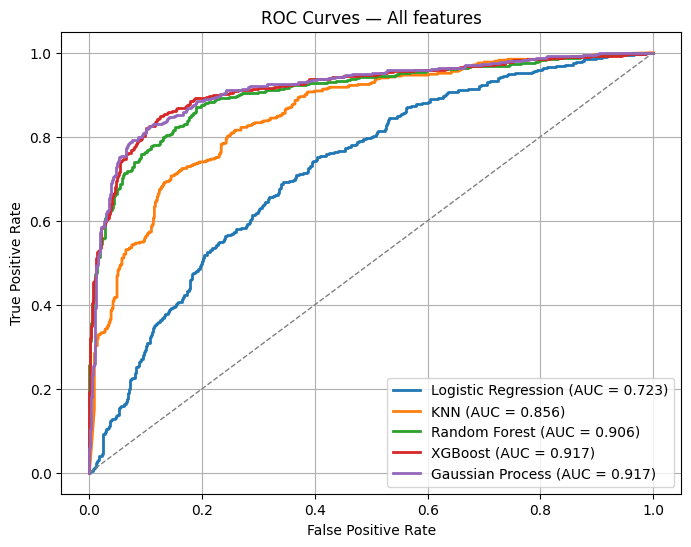

In [4]:
evaluate_models_cv_with_tuning(X_resampled, y_resampled, "All features")
